In [238]:
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


In [239]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

SEED = 122
TEST_YEARS = 5

HORIZON = 1
VOL_WINDOW = 26
K_LAGS = 52

PAST_VOL_WINDOWS = (4, 8, 13, 26, 52)

VAL_FRAC = 0.2
EPS = 1e-8

SIGNAL_CHANGE_WINDOW = 8
SIGNAL_THRESHOLD = 1.0

set_seed(SEED)


In [240]:
DATA_PATH = r"C:\Programming\ETH\SS26\ISQT26\final\playground\market_data.xlsx"

df = pd.read_excel(DATA_PATH, sheet_name="US", engine="openpyxl", index_col=0)
namings = pd.read_excel(DATA_PATH, sheet_name="legend", engine="openpyxl", index_col=0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()


In [241]:
def build_vol_dataset(df, target="_MKT", horizon=1, window=4, past_vol_windows=(4, 8, 13, 26, 52)):

    X = df.drop(columns=[target])
    Y = df[target]

    def safe_log(s):
        return np.log(s.where(s > 0))

    def dlog(s):
        return np.log(s / s.shift(horizon))

    def fisher(s):
        rho = s.clip(-1 + 1e-6, 1 - 1e-6)
        return np.arctanh(rho)

    def logit_prob(s):
        p = (s / 100).clip(1e-6, 1 - 1e-6)
        return np.log(p / (1 - p))

    Z = pd.DataFrame(index=df.index)

    Z["EMP"]  = X["EMP"]
    Z["PE"]   = safe_log(X["PE"])
    Z["CAPE"] = safe_log(X["CAPE"])
    Z["DY"]   = safe_log(X["DY"])
    Z["Rho"]  = fisher(X["Rho"])
    Z["MOV "] = safe_log(X["MOV "])

    Z["IR"]   = X["IR"]
    Z["RR"]   = X["RR"]
    Z["Y02"]  = X["Y02"]
    Z["Y10"]  = X["Y10"]
    Z["STP"]  = X["STP"]

    Z["CF"]   = X["CF"]
    Z["MG"]   = X["MG"]
    Z["RV"]   = X["RV"]
    Z["ED"]   = X["ED"]
    Z["UN"]   = X["UN"]
    Z["GDP"]  = X["GDP"]
    Z["M2"]   = X["M2"]
    Z["CPI"]  = X["CPI"]
    Z["DIL"]  = X["DIL"]

    Z["YSS"]  = np.log1p(X["YSS"])
    Z["NYF"]  = logit_prob(X["NYF"])

    Z["_AU"]  = dlog(X["_AU"])
    Z["_DXY"] = dlog(X["_DXY"])
    Z["_LCP"] = dlog(X["_LCP"])
    Z["_TY"]  = dlog(X["_TY"])
    Z["_OIL"] = dlog(X["_OIL"])

    Z["_VA"]  = dlog(X["_VA"])
    Z["_GR"]  = dlog(X["_GR"])

    mkt_ret = np.log(Y / Y.shift(1))

    Z["_MKT_ret_1"] = mkt_ret
    Z["_MKT_absret_1"] = mkt_ret.abs()

    for w in past_vol_windows:
        Z[f"_MKT_vol_{w}"] = mkt_ret.rolling(w).std(ddof=0)

    Z["_MKT_ewm_vol_13"] = mkt_ret.ewm(span=13, adjust=False).std(bias=True)
    Z["_MKT_ewm_vol_26"] = mkt_ret.ewm(span=26, adjust=False).std(bias=True)

    y_sigma = pd.Series(index=df.index, dtype=float)
    y_end_date = pd.Series(index=df.index, dtype="datetime64[ns]")

    for t in range(len(df)):
        start = t + horizon
        end = start + window

        if end <= len(df):
            rr = mkt_ret.iloc[start:end]

            if rr.notna().all():
                y_sigma.iloc[t] = rr.std(ddof=0)
                y_end_date.iloc[t] = df.index[end - 1]

    data = pd.concat(
        [
            Z,
            y_sigma.rename("y_sigma"),
            y_end_date.rename("y_end_date"),
        ],
        axis=1,
    )

    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    return data


In [242]:
def split_and_standardize(data, test_years=5):
    split_date = data.index.max() - pd.DateOffset(years=test_years)

    train = data.loc[data["y_end_date"] < split_date].copy()
    test = data.loc[data.index >= split_date].copy()

    feature_cols = [c for c in data.columns if c not in ["y_sigma", "y_end_date"]]

    X_train_raw = train[feature_cols]
    X_test_raw = test[feature_cols]

    y_train_raw = train["y_sigma"]
    y_test_raw = test["y_sigma"]

    params = {
        "X_mean": X_train_raw.mean(),
        "X_std": X_train_raw.std(ddof=0).replace(0, 1),
        "Y_mean": y_train_raw.mean(),
        "Y_std": y_train_raw.std(ddof=0) if y_train_raw.std(ddof=0) != 0 else 1,
    }

    X_train = (X_train_raw - params["X_mean"]) / params["X_std"]
    X_test = (X_test_raw - params["X_mean"]) / params["X_std"]

    y_train = (y_train_raw - params["Y_mean"]) / params["Y_std"]
    y_test = (y_test_raw - params["Y_mean"]) / params["Y_std"]

    return X_train, X_test, y_train, y_test, y_train_raw, y_test_raw, params, feature_cols, split_date


In [243]:
def make_rnn_windows(X, y, k):
    data = pd.concat([X, y.rename("target")], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    X_values = data.drop(columns=["target"]).to_numpy(dtype=np.float32)
    y_values = data["target"].to_numpy(dtype=np.float32)

    X_seq = []
    y_seq = []
    idx = []

    for end in range(k - 1, len(data)):
        start = end - k + 1
        X_seq.append(X_values[start:end + 1])
        y_seq.append(y_values[end])
        idx.append(data.index[end])

    X_seq = torch.tensor(np.asarray(X_seq), dtype=torch.float32)
    y_seq = torch.tensor(np.asarray(y_seq).reshape(-1, 1), dtype=torch.float32)

    return X_seq, y_seq, pd.DatetimeIndex(idx)


In [244]:
vol_data = build_vol_dataset(
    df,
    target="_MKT",
    horizon=HORIZON,
    window=VOL_WINDOW,
    past_vol_windows=PAST_VOL_WINDOWS,
)

X_train, X_test, Y_train, Y_test, Y_train_sigma, Y_test_sigma, params, feature_cols, split_date = split_and_standardize(
    vol_data,
    test_years=TEST_YEARS,
)

X_train_rnn, Y_train_rnn, train_idx = make_rnn_windows(X_train, Y_train, K_LAGS)
X_test_rnn, Y_test_rnn, test_idx = make_rnn_windows(X_test, Y_test, K_LAGS)

val_start = int(len(X_train_rnn) * (1 - VAL_FRAC))

X_tr_rnn = X_train_rnn[:val_start]
Y_tr_rnn = Y_train_rnn[:val_start]

X_val_rnn = X_train_rnn[val_start:]
Y_val_rnn = Y_train_rnn[val_start:]

train_fit_idx = train_idx[:val_start]
val_idx = train_idx[val_start:]

n_features = X_train_rnn.shape[2]

print("Features:", n_features)
print("Train sequences:", X_tr_rnn.shape)
print("Validation sequences:", X_val_rnn.shape)
print("Test sequences:", X_test_rnn.shape)
print("Split date:", split_date)


Features: 38
Train sequences: torch.Size([1256, 52, 38])
Validation sequences: torch.Size([315, 52, 38])
Test sequences: torch.Size([210, 52, 38])
Split date: 2020-11-02 00:00:00


In [245]:
class VolRNN(torch.nn.Module):
    def __init__(self, n_features, hidden_size=8, num_layers=1, dropout=0.0, cell="GRU", seed=0):
        super().__init__()
        set_seed(seed)

        self.cell = cell.upper()

        if self.cell == "RNN":
            self.rnn = torch.nn.RNN(
                input_size=n_features,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0.0,
                batch_first=True,
                nonlinearity="tanh",
            )
        elif self.cell == "LSTM":
            self.rnn = torch.nn.LSTM(
                input_size=n_features,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0.0,
                batch_first=True,
            )
        else:
            self.rnn = torch.nn.GRU(
                input_size=n_features,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0.0,
                batch_first=True,
            )

        self.head = torch.nn.Sequential(
            torch.nn.LayerNorm(hidden_size),
            torch.nn.Linear(hidden_size, 1),
        )

    def forward(self, X):
        h, _ = self.rnn(X)
        return self.head(h[:, -1, :])


In [246]:
def tensor_metrics(y_true, y_pred):
    with torch.no_grad():
        err = y_pred - y_true
        rmse = torch.sqrt(torch.mean(err ** 2)).item()
        mae = torch.mean(torch.abs(err)).item()
        hit = (torch.sign(y_pred) == torch.sign(y_true)).float().mean().item()

    return {
        "hit": hit,
        "rmse": rmse,
        "mae": mae,
    }


def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        pred = model(X)
    return tensor_metrics(y, pred)


def predict_model(model, X):
    model.eval()
    with torch.no_grad():
        return model(X).detach().cpu().numpy().ravel()


In [247]:
def train_rnn(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    lr=1e-3,
    weight_decay=1e-3,
    epochs=1000,
    patience=100,
    clip_grad=1.0,
    show_progress=True,
):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = torch.nn.MSELoss()

    hist = {
        "train_hit": [],
        "val_hit": [],
        "train_rmse": [],
        "val_rmse": [],
        "train_mae": [],
        "val_mae": [],
    }

    best_state = None
    best_val = np.inf
    wait = 0

    iterator = tqdm(range(epochs), desc="Training") if show_progress else range(epochs)

    for _ in iterator:
        model.train()
        opt.zero_grad()

        pred_train = model(X_train)
        loss = loss_fn(pred_train, y_train)
        loss.backward()

        if clip_grad is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        opt.step()

        model.eval()
        with torch.no_grad():
            pred_train = model(X_train)
            pred_val = model(X_val)
            val_loss = loss_fn(pred_val, y_val).item()

        train_m = tensor_metrics(y_train, pred_train)
        val_m = tensor_metrics(y_val, pred_val)

        hist["train_hit"].append(train_m["hit"])
        hist["val_hit"].append(val_m["hit"])
        hist["train_rmse"].append(train_m["rmse"])
        hist["val_rmse"].append(val_m["rmse"])
        hist["train_mae"].append(train_m["mae"])
        hist["val_mae"].append(val_m["mae"])

        if val_loss < best_val - 1e-8:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if show_progress:
            iterator.set_postfix({
                "train_hit": f"{train_m['hit']:.3f}",
                "val_hit": f"{val_m['hit']:.3f}",
                "train_rmse": f"{train_m['rmse']:.3f}",
                "val_rmse": f"{val_m['rmse']:.3f}",
                "val_mae": f"{val_m['mae']:.3f}",
            })

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    hist["model"] = model
    return hist


In [248]:
hidden_size = 8
num_layers = 1
cell = "GRU"

model = VolRNN(
    n_features=n_features,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=0.0,
    cell=cell,
    seed=SEED,
)

hist = train_rnn(
    model,
    X_tr_rnn,
    Y_tr_rnn,
    X_val_rnn,
    Y_val_rnn,
    lr=1e-3,
    weight_decay=1e-3,
    epochs=1000,
    patience=100,
    clip_grad=1.0,
)


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [249]:
metrics = pd.DataFrame(
    {
        "train": evaluate_model(model, X_tr_rnn, Y_tr_rnn),
        "validation": evaluate_model(model, X_val_rnn, Y_val_rnn),
        "test": evaluate_model(model, X_test_rnn, Y_test_rnn),
    }
).T

metrics


,hit,rmse,mae
train,0.844745,0.636109,0.417911
validation,0.641270,1.259267,0.808318
test,0.480952,0.784635,0.659997


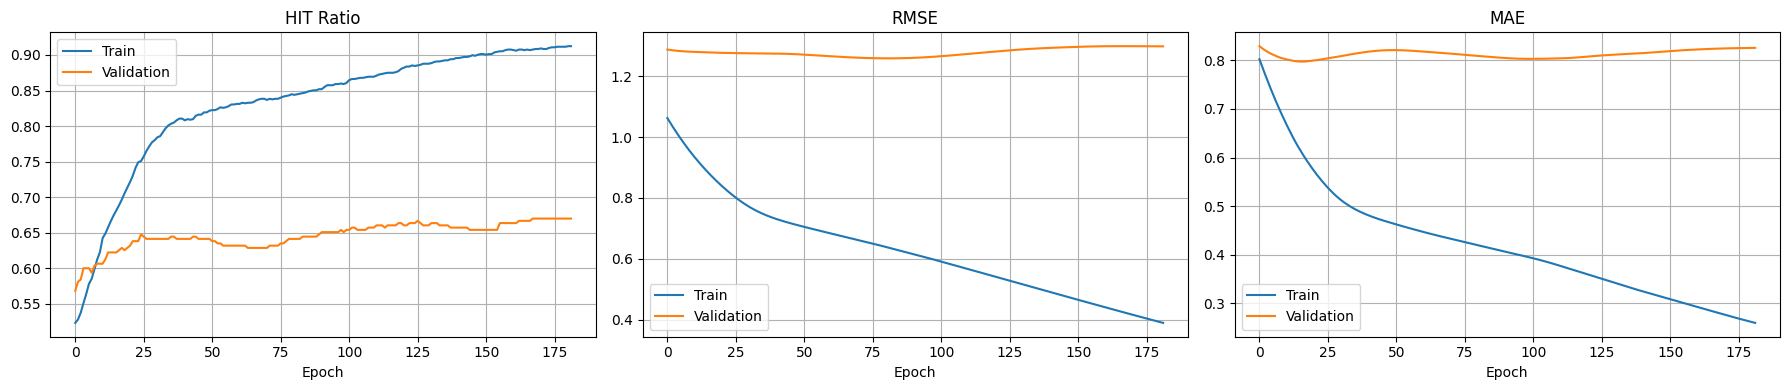

In [250]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hist["train_hit"], label="Train")
axes[0].plot(hist["val_hit"], label="Validation")
axes[0].set_title("HIT Ratio")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist["train_rmse"], label="Train")
axes[1].plot(hist["val_rmse"], label="Validation")
axes[1].set_title("RMSE")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(hist["train_mae"], label="Train")
axes[2].plot(hist["val_mae"], label="Validation")
axes[2].set_title("MAE")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


In [251]:
test_pred = predict_model(model, X_test_rnn)
test_actual = Y_test_rnn.detach().cpu().numpy().ravel()

pred = pd.DataFrame(
    {
        "actual_vol_z": test_actual,
        "predicted_vol_z": test_pred,
    },
    index=test_idx,
)

pred.tail()


,actual_vol_z,predicted_vol_z
2025-10-05,-0.398778,-0.187196
2025-10-12,-0.346943,-0.047371
2025-10-19,-0.165052,-0.104030
2025-10-26,-0.192238,-0.108262
2025-11-02,-0.188782,-0.130835


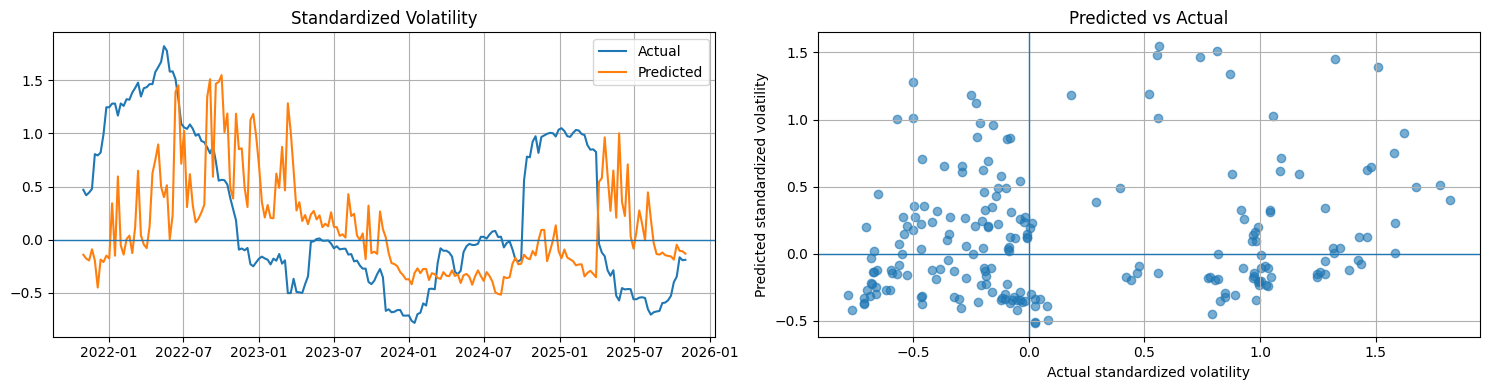

In [252]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(pred.index, pred["actual_vol_z"], label="Actual")
axes[0].plot(pred.index, pred["predicted_vol_z"], label="Predicted")
axes[0].axhline(0.0, linewidth=1)
axes[0].set_title("Standardized Volatility")
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(pred["actual_vol_z"], pred["predicted_vol_z"], alpha=0.6)
axes[1].axhline(0.0, linewidth=1)
axes[1].axvline(0.0, linewidth=1)
axes[1].set_xlabel("Actual standardized volatility")
axes[1].set_ylabel("Predicted standardized volatility")
axes[1].set_title("Predicted vs Actual")
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [253]:
SIGNAL_CHANGE_WINDOW = 26
SIGNAL_THRESHOLD = 1


def run_self_financing_vol_strategy(
    pred,
    df,
    target="_MKT",
    signal_change_window=8,
    threshold=0.75,
):
    bt = pred.copy()
    bt["MKT"] = df[target].reindex(bt.index)
    bt = bt.dropna().copy()

    bt["predicted_vol_change_z"] = bt["predicted_vol_z"].diff(signal_change_window)

    if "actual_vol_z" in bt.columns:
        bt["actual_vol_change_z"] = bt["actual_vol_z"].diff(signal_change_window)

    bt["mkt_return"] = bt["MKT"].pct_change()
    bt["mkt_diff"] = bt["MKT"].diff()

    diagnostics = {
        "corr_mkt_return_predicted_vol_z": bt["mkt_return"].corr(bt["predicted_vol_z"]),
        "corr_mkt_return_predicted_vol_change_z": bt["mkt_return"].corr(bt["predicted_vol_change_z"]),
    }

    if "actual_vol_z" in bt.columns:
        diagnostics["corr_mkt_return_actual_vol_z"] = bt["mkt_return"].corr(bt["actual_vol_z"])

    if "actual_vol_change_z" in bt.columns:
        diagnostics["corr_mkt_return_actual_vol_change_z"] = bt["mkt_return"].corr(bt["actual_vol_change_z"])

    cash = 0.0
    shares = 1.0

    strategy_value = []
    cash_path = []
    shares_path = []
    signal_path = []

    for i, (_, row) in enumerate(bt.iterrows()):
        price = row["MKT"]

        if i == 0:
            value = cash + shares * price
            strategy_value.append(value)
            cash_path.append(cash)
            shares_path.append(shares)
            signal_path.append(0.0)
            continue

        value = cash + shares * price
        x = row["predicted_vol_change_z"]

        desired_shares = shares
        signal = 0.0

        if pd.notna(x):
            if x >= threshold:
                desired_shares = 0.0
                signal = -1.0
            elif x <= -threshold:
                desired_shares = 1.0
                signal = 1.0

        if desired_shares < shares:
            sell_qty = shares - desired_shares
            cash += sell_qty * price
            shares -= sell_qty

        elif desired_shares > shares:
            buy_qty = min(desired_shares - shares, cash / price, 1.0 - shares)
            cash -= buy_qty * price
            shares += buy_qty

        value = cash + shares * price

        strategy_value.append(value)
        cash_path.append(cash)
        shares_path.append(shares)
        signal_path.append(signal)

    bt["cash"] = cash_path
    bt["shares"] = shares_path
    bt["signal"] = signal_path
    bt["strategy_value"] = strategy_value

    bt["baseline_value"] = bt["MKT"]
    bt["active_value"] = bt["strategy_value"] - bt["baseline_value"]

    bt["strategy_return"] = bt["strategy_value"] / bt["strategy_value"].iloc[0] - 1.0
    bt["baseline_return"] = bt["baseline_value"] / bt["baseline_value"].iloc[0] - 1.0
    bt["active_return"] = bt["strategy_return"] - bt["baseline_return"]

    strategy_pnl = bt["strategy_value"].diff().dropna()
    baseline_pnl = bt["baseline_value"].diff().dropna()
    active_pnl = strategy_pnl - baseline_pnl

    active_sr = active_pnl.mean() / active_pnl.std() * np.sqrt(52) if active_pnl.std() > 0 else np.nan

    trades = bt["shares"].diff().abs().fillna(0.0)

    metrics = pd.Series({
        "final_strategy_value": bt["strategy_value"].iloc[-1],
        "final_baseline_value": bt["baseline_value"].iloc[-1],
        "final_active_value": bt["active_value"].iloc[-1],
        "strategy_return": bt["strategy_return"].iloc[-1],
        "baseline_return": bt["baseline_return"].iloc[-1],
        "active_return": bt["active_return"].iloc[-1],
        "active_sr": active_sr,
        "mean_shares": bt["shares"].mean(),
        "time_in_market": (bt["shares"] > 0).mean(),
        "number_of_trades": trades[trades > 0].count(),
        "total_turnover_units": trades.sum(),
        "threshold": threshold,
        "signal_change_window": signal_change_window,
        **diagnostics,
    })

    return bt, metrics


strategy_bt, strategy_metrics = run_self_financing_vol_strategy(
    pred,
    df,
    target="_MKT",
    signal_change_window=SIGNAL_CHANGE_WINDOW,
    threshold=SIGNAL_THRESHOLD,
)

strategy_metrics

final_strategy_value                      21719.510349
final_baseline_value                      27409.110000
final_active_value                        -5689.599651
strategy_return                               0.202865
baseline_return                               0.517965
active_return                                -0.315100
active_sr                                    -0.696648
mean_shares                                   0.663701
time_in_market                                0.666667
number_of_trades                              4.000000
total_turnover_units                          3.792419
threshold                                     1.000000
signal_change_window                         26.000000
corr_mkt_return_predicted_vol_z              -0.317145
corr_mkt_return_predicted_vol_change_z       -0.305849
corr_mkt_return_actual_vol_z                 -0.190034
corr_mkt_return_actual_vol_change_z          -0.139459
dtype: float64

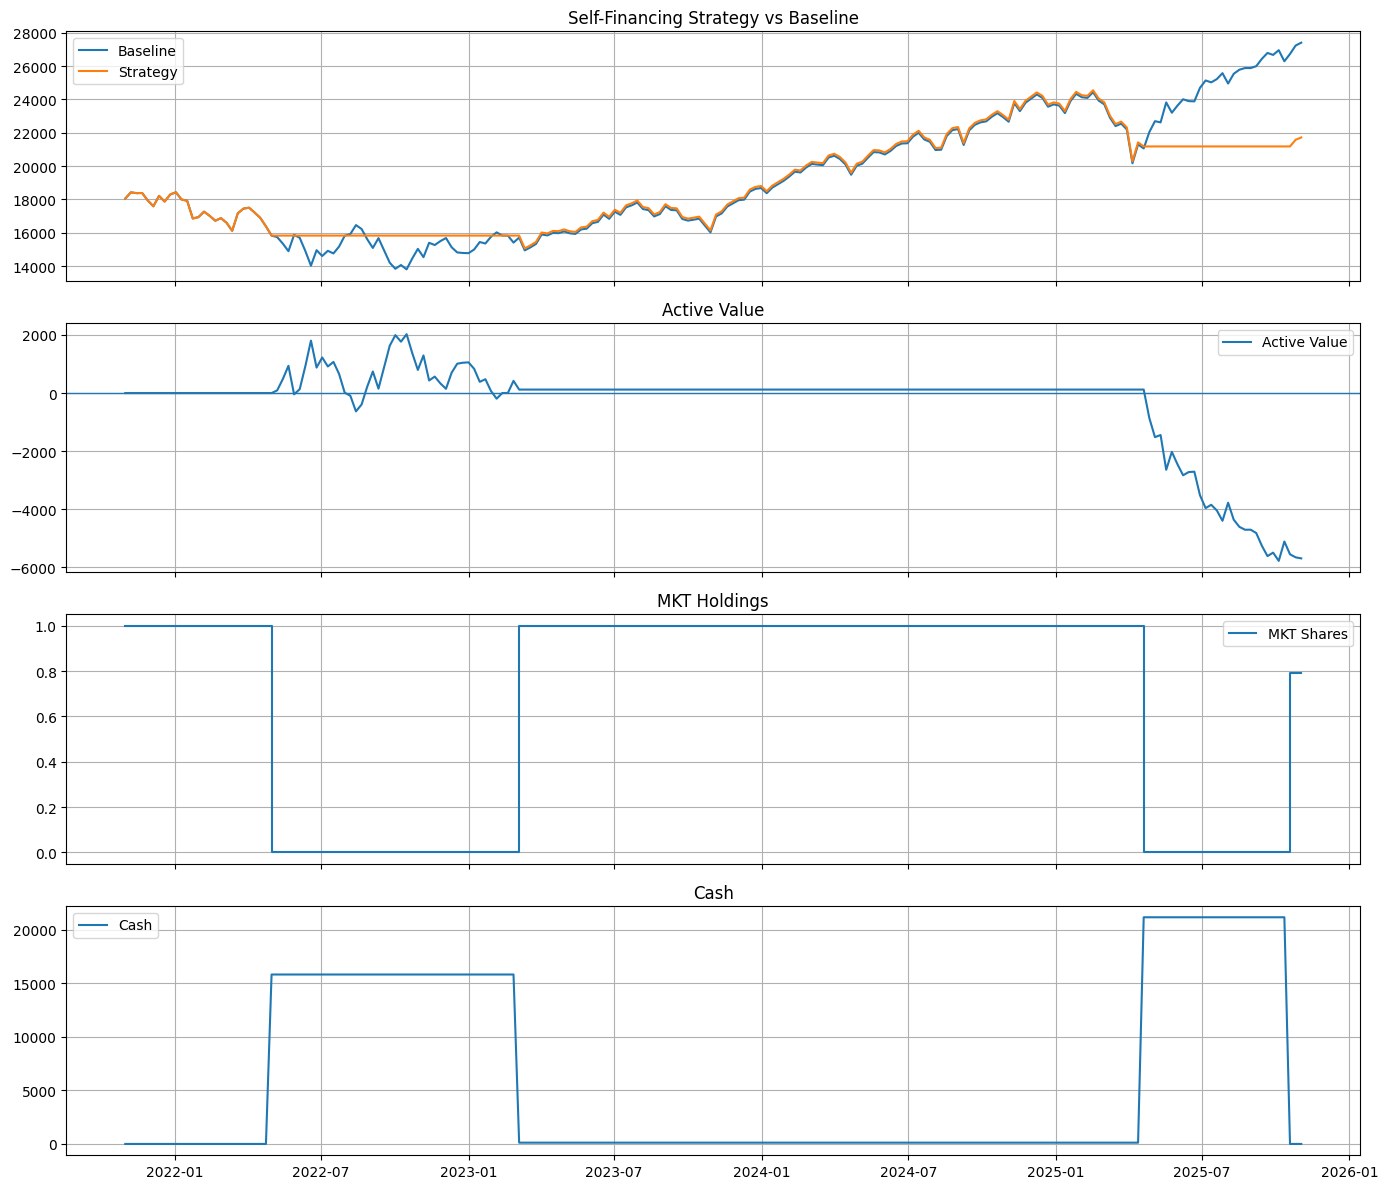

In [254]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(strategy_bt.index, strategy_bt["baseline_value"], label="Baseline")
axes[0].plot(strategy_bt.index, strategy_bt["strategy_value"], label="Strategy")
axes[0].set_title("Self-Financing Strategy vs Baseline")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(strategy_bt.index, strategy_bt["active_value"], label="Active Value")
axes[1].axhline(0.0, linewidth=1)
axes[1].set_title("Active Value")
axes[1].legend()
axes[1].grid(True)

axes[2].step(strategy_bt.index, strategy_bt["shares"], where="post", label="MKT Shares")
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_title("MKT Holdings")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(strategy_bt.index, strategy_bt["cash"], label="Cash")
axes[3].set_title("Cash")
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

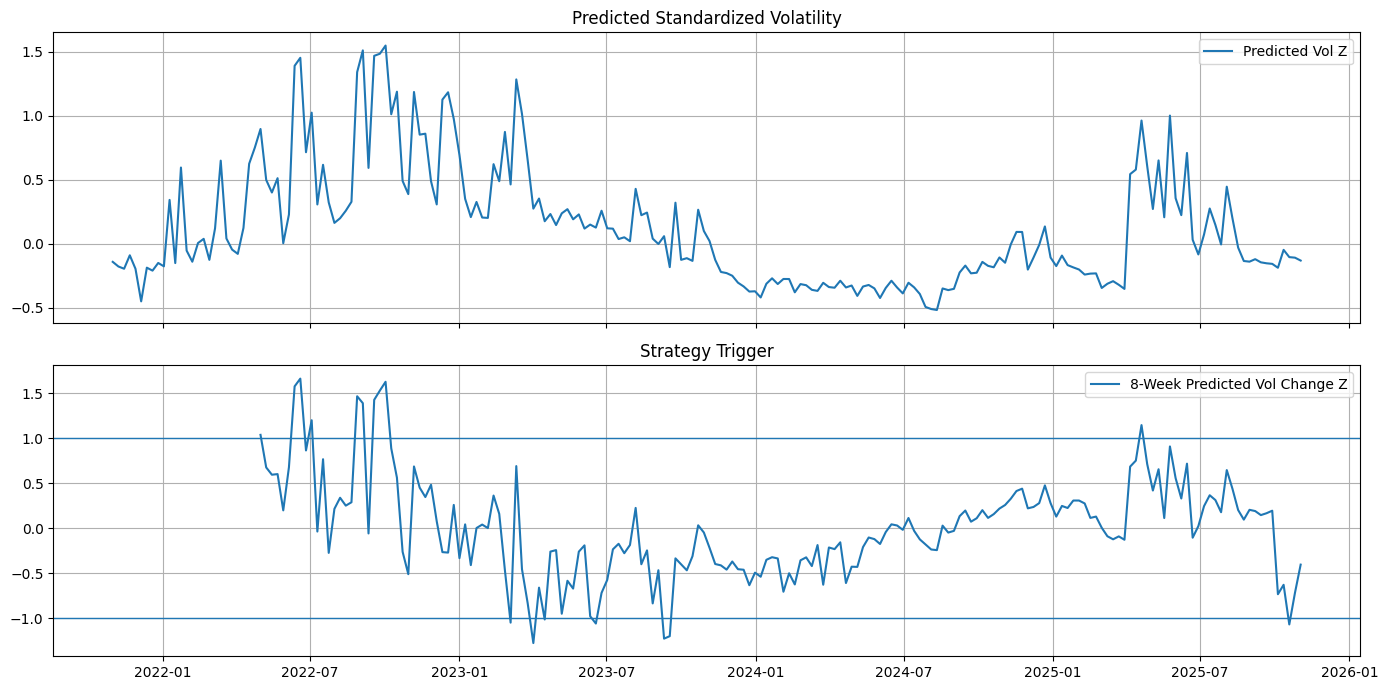

In [255]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(strategy_bt.index, strategy_bt["predicted_vol_z"], label="Predicted Vol Z")
axes[0].set_title("Predicted Standardized Volatility")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(strategy_bt.index, strategy_bt["predicted_vol_change_z"], label="8-Week Predicted Vol Change Z")
axes[1].axhline(SIGNAL_THRESHOLD, linewidth=1)
axes[1].axhline(-SIGNAL_THRESHOLD, linewidth=1)
axes[1].set_title("Strategy Trigger")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

predicted_trigger_count         17
actual_trigger_count            68
same_direction_trigger_count     4
predicted_sell_count            10
predicted_buy_count              7
actual_sell_count               20
actual_buy_count                48
missed_actual_triggers          64
false_predicted_triggers        13
dtype: int64

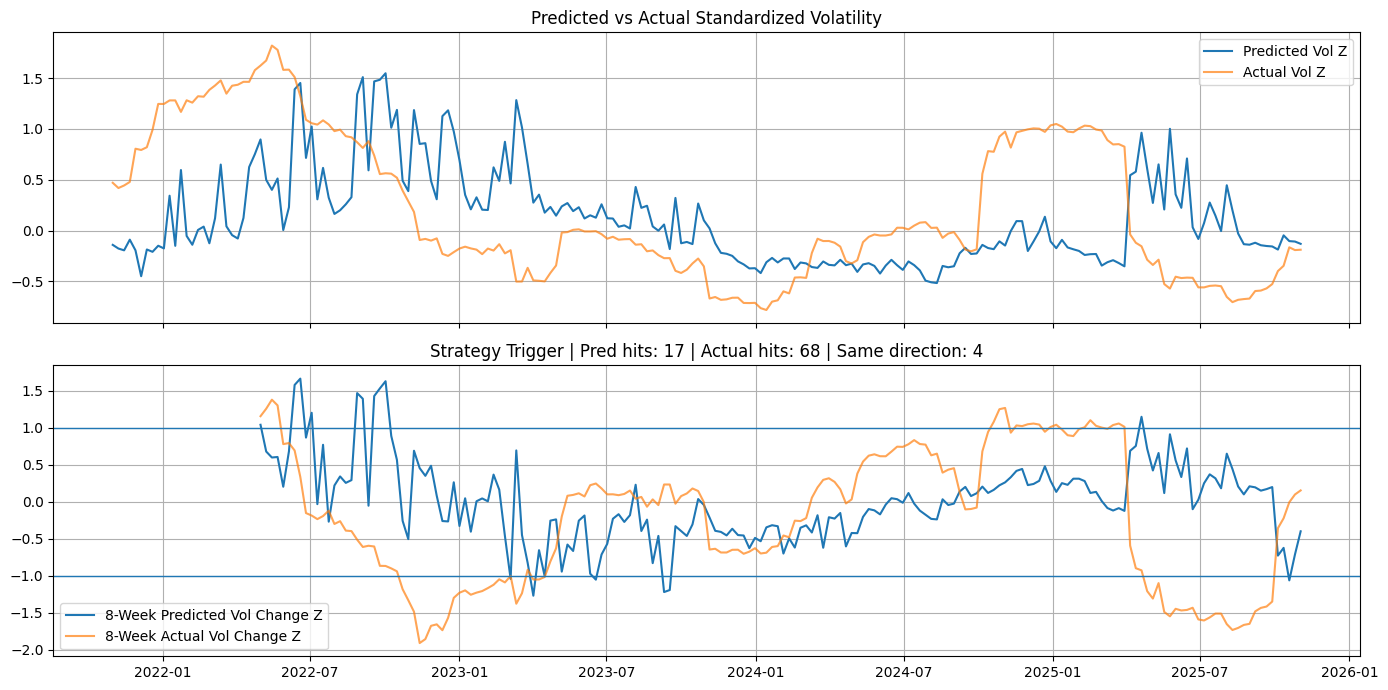

In [256]:
if "actual_vol_change_z" not in strategy_bt.columns:
    strategy_bt["actual_vol_change_z"] = strategy_bt["actual_vol_z"].diff(SIGNAL_CHANGE_WINDOW)

pred_sell = strategy_bt["predicted_vol_change_z"] >= SIGNAL_THRESHOLD
pred_buy = strategy_bt["predicted_vol_change_z"] <= -SIGNAL_THRESHOLD
pred_hit = pred_sell | pred_buy

actual_sell = strategy_bt["actual_vol_change_z"] >= SIGNAL_THRESHOLD
actual_buy = strategy_bt["actual_vol_change_z"] <= -SIGNAL_THRESHOLD
actual_hit = actual_sell | actual_buy

same_direction_hit = (pred_sell & actual_sell) | (pred_buy & actual_buy)

hit_stats = pd.Series({
    "predicted_trigger_count": pred_hit.sum(),
    "actual_trigger_count": actual_hit.sum(),
    "same_direction_trigger_count": same_direction_hit.sum(),
    "predicted_sell_count": pred_sell.sum(),
    "predicted_buy_count": pred_buy.sum(),
    "actual_sell_count": actual_sell.sum(),
    "actual_buy_count": actual_buy.sum(),
    "missed_actual_triggers": (actual_hit & ~pred_hit).sum(),
    "false_predicted_triggers": (pred_hit & ~actual_hit).sum(),
})

display(hit_stats)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(strategy_bt.index, strategy_bt["predicted_vol_z"], label="Predicted Vol Z")
axes[0].plot(strategy_bt.index, strategy_bt["actual_vol_z"], label="Actual Vol Z", alpha=0.7)
axes[0].set_title("Predicted vs Actual Standardized Volatility")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(strategy_bt.index, strategy_bt["predicted_vol_change_z"], label="8-Week Predicted Vol Change Z")
axes[1].plot(strategy_bt.index, strategy_bt["actual_vol_change_z"], label="8-Week Actual Vol Change Z", alpha=0.7)
axes[1].axhline(SIGNAL_THRESHOLD, linewidth=1)
axes[1].axhline(-SIGNAL_THRESHOLD, linewidth=1)
axes[1].set_title(
    f"Strategy Trigger | Pred hits: {pred_hit.sum()} | Actual hits: {actual_hit.sum()} | Same direction: {same_direction_hit.sum()}"
)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [257]:
strategy_bt[
    [
        "MKT",
        "predicted_vol_z",
        "predicted_vol_change_z",
        "shares",
        "cash",
        "strategy_value",
        "baseline_value",
        "active_value",
    ]
].tail(20)

,MKT,predicted_vol_z,predicted_vol_change_z,shares,cash,strategy_value,baseline_value,active_value
2025-06-22,23887.85,0.031655,-0.103798,0.000000,21182.25,21182.250000,23887.85,-2705.600000
2025-06-29,24698.27,-0.083032,0.024500,0.000000,21182.25,21182.250000,24698.27,-3516.020000
2025-07-06,25141.13,0.072454,0.246281,0.000000,21182.25,21182.250000,25141.13,-3958.880000
2025-07-13,25027.30,0.275392,0.367277,0.000000,21182.25,21182.250000,25027.30,-3845.050000
2025-07-20,25223.21,0.147293,0.313619,0.000000,21182.25,21182.250000,25223.21,-4040.960000
2025-07-27,25578.74,-0.005292,0.178938,0.000000,21182.25,21182.250000,25578.74,-4396.490000
2025-08-03,24956.18,0.445631,0.646341,0.000000,21182.25,21182.250000,24956.18,-3773.930000
2025-08-10,25540.94,0.198888,0.439200,0.000000,21182.25,21182.250000,25540.94,-4358.690000
2025-08-17,25786.02,-0.029500,0.203272,0.000000,21182.25,21182.250000,25786.02,-4603.770000
2025-08-24,25886.07,-0.134275,0.096728,0.000000,21182.25,21182.250000,25886.07,-4703.820000
